한국어 `ChatbotData.csv` 데이터셋을 이용하여 SentencePiece 기반 Transformer Encoder-Decoder 챗봇 학습하기

In [ ]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


In [ ]:
!pip install sentencepiece

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# 최대 시퀀스 길이(전처리 max_length와 동일). 포지셔널 인코딩의 position 인자로 사용합니다.
MAX_LENGTH = 20

# Data

## Data Preparation

In [ ]:
import pandas as pd

# ChatbotData.csv 다운로드 URL
url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
csv_filename = 'ChatbotData.csv'

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(csv_filename):
    print(f"Downloading {csv_filename} ...")
    urllib.request.urlretrieve(url, csv_filename)
    print("Download complete.")

# CSV 파일 불러오기
data = pd.read_csv(csv_filename)

print("데이터 크기:", data.shape)
data.head()

데이터 크기: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [ ]:
# label 컬럼은 제외
data = data.drop(['label'], axis=1)

## EDA

In [ ]:
print('========== data.shape ==========')
print(data.shape)
print('========== data.info() ==========')
print(data.info())

========== data.shape ==========
(11823, 2)
========== data.info() ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
dtypes: object(2)
memory usage: 184.9+ KB
None


## Data Preprocessing

In [ ]:
# 공백 제거
data['Q'] = data['Q'].str.strip()
data['A'] = data['A'].str.strip()

# 연속된 공백 하나로 변경
data['Q'] = data['Q'].str.replace(r'\s+', ' ', regex=True)
data['A'] = data['A'].str.replace(r'\s+', ' ', regex=True)

# 중복 제거
data = data.drop_duplicates()

# index 초기화
data = data.reset_index(drop=True)

print(data.shape)
display(data.sample(10))

(11750, 2)


,Q,A
7013,여자친구 무시했다가 이별 당했습니다.,남을 질타하면 그것은 언젠간 자신에게 돌아와요.
7045,"연락왔는데,진짜 미칠거같네",다시 헤어진 그 때로 돌아간 느낌이죠.
808,내 이름이 없어,확인해달라고 해보세요.
2057,베란다도 꾸미니까 예쁘더라.,심플하게 꾸며보세요.
190,고시원 너무 답답해,돈을 모아서 다른 곳으로 이사갈 수 있을 거예요.
5719,꿈꾸니까 진짜 힘드네ㅜ,꿈이 웬수네요.
3762,인내하면 얻을 수 있을까?,인내할 수 있는 사람이라면 무엇이든 손에 넣을 수 있을 거예요.
937,너 미워,모두 제 잘못입니다.
4586,친구 따라다녀야겠다.,친구가 따라오게 해보세요.
2659,스키 배워보고 싶다.,배우면 금방 배우실 거예요.


In [ ]:
questions = data['Q'].values
answers = data['A'].values

# Tokenizer

## Corpus for SentencePiece Training

In [ ]:
corpus_file = "clean_corpus.txt"

with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in zip(questions, answers):
        f.write(q + "\n")
        f.write(a + "\n")

## SentencePiece training

In [ ]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_chatbot",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,      # <s>
    eos_id=2,      # </s>
    pad_id=0,      # <pad>
    unk_id=3       # <unk>
)

True

In [ ]:
# SentencePiece 테스트

sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

test_sentences = [
    "오늘 기분이 어때?",
    "너는 누구야?",
    "밥 먹었어?",
    "요즘 너무 힘들어.",
    "안녕하세요.",
    "고마워!"
]

for sentence in test_sentences:
    tokens = sp.encode(sentence, out_type=str)
    ids = sp.encode(sentence, out_type=int)
    decoded = sp.decode(ids)

    print("=" * 50)
    print("원문 :", sentence)
    print("토큰 :", tokens)
    print("ID   :", ids)
    print("복원 :", decoded)

원문 : 오늘 기분이 어때?
토큰 : ['▁오늘', '▁기분이', '▁어때', '?']
ID   : [125, 929, 643, 6789]
복원 : 오늘 기분이 어때?
원문 : 너는 누구야?
토큰 : ['▁너는', '▁누구', '야', '?']
ID   : [3628, 483, 6811, 6789]
복원 : 너는 누구야?
원문 : 밥 먹었어?
토큰 : ['▁밥', '▁먹었어', '?']
ID   : [731, 5037, 6789]
복원 : 밥 먹었어?
원문 : 요즘 너무 힘들어.
토큰 : ['▁요즘', '▁너무', '▁힘들어', '.']
ID   : [693, 54, 417, 6760]
복원 : 요즘 너무 힘들어.
원문 : 안녕하세요.
토큰 : ['▁안녕하세요', '.']
ID   : [4585, 6760]
복원 : 안녕하세요.
원문 : 고마워!
토큰 : ['▁고마워', '!']
ID   : [3744, 6910]
복원 : 고마워!


In [ ]:
print("PAD:", sp.pad_id())
print("BOS:", sp.bos_id())
print("EOS:", sp.eos_id())
print("UNK:", sp.unk_id())

PAD: 0
BOS: 1
EOS: 2
UNK: 3


## Determine max_length based on token length
- 최종적으로 20으로 선택

In [ ]:
q_lengths = []
a_lengths = []

for q, a in zip(questions, answers):
    q_ids = sp.encode(q, out_type=int)
    a_ids = sp.encode(a, out_type=int)

    # BOS + EOS 포함
    q_lengths.append(len(q_ids) + 2)
    a_lengths.append(len(a_ids) + 2)

q_lengths = np.array(q_lengths)
a_lengths = np.array(a_lengths)

print("질문")
print("평균:", q_lengths.mean())
print("최대:", q_lengths.max())
print("95%:", np.percentile(q_lengths, 95))
print("99%:", np.percentile(q_lengths, 99))

print("\n답변")
print("평균:", a_lengths.mean())
print("최대:", a_lengths.max())
print("95%:", np.percentile(a_lengths, 95))
print("99%:", np.percentile(a_lengths, 99))

질문
평균: 7.417531914893617
최대: 23
95%: 12.0
99%: 15.0

답변
평균: 7.797106382978724
최대: 31
95%: 12.0
99%: 16.0


In [ ]:
for max_length in [16, 20, 24, 32]:
    removed = sum(
        len(sp.encode(q, out_type=int)) + 2 > max_length or
        len(sp.encode(a, out_type=int)) + 2 > max_length
        for q, a in zip(questions, answers)
    )

    print(
        f"max_length={max_length}: "
        f"{removed}개 제거 "
        f"({removed / len(questions) * 100:.2f}%)"
    )

max_length=16: 148개 제거 (1.26%)
max_length=20: 34개 제거 (0.29%)
max_length=24: 8개 제거 (0.07%)
max_length=32: 0개 제거 (0.00%)


# Dataset, Dataloader

## Dataset

In [ ]:
class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp, max_length=40):
        super().__init__()

        self.sp = sp
        self.max_length = max_length
        self.data = []

        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        pad_id = sp.pad_id()

        for q_text, a_text in zip(questions, answers):

            # 1. SentencePiece 토크나이즈
            q_ids = sp.encode(q_text, out_type=int)
            a_ids = sp.encode(a_text, out_type=int)

            # 2. Encoder input
            enc_input = [bos_id] + q_ids + [eos_id]

            # 3. Decoder 전체 sequence
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 4. 길이 제한
            if len(enc_input) > max_length:
                continue

            if len(a_tokens) > max_length:
                continue

            # 5. Teacher Forcing을 위해 먼저 shift
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            # 6. Padding
            enc_input += [pad_id] * (max_length - len(enc_input))
            dec_input += [pad_id] * (max_length - len(dec_input))
            target += [pad_id] * (max_length - len(target))

            self.data.append({
                "enc_input": enc_input,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        enc_input = torch.tensor(
            sample["enc_input"],
            dtype=torch.long
        )

        dec_input = torch.tensor(
            sample["dec_input"],
            dtype=torch.long
        )

        target = torch.tensor(
            sample["target"],
            dtype=torch.long
        )

        return enc_input, dec_input, target

In [ ]:
dataset = ChatbotDataset(
    questions,
    answers,
    sp,
    max_length=20
)

print("Dataset size:", len(dataset))

Dataset size: 11716


In [ ]:
enc_input, dec_input, target = dataset[0]

print("Encoder input:")
print(enc_input)

print("\nDecoder input:")
print(dec_input)

print("\nTarget:")
print(target)

Encoder input:
tensor([   1, 5536, 6801, 3184, 6910,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Decoder input:
tensor([   1, 4452,  210, 5900, 6760,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Target:
tensor([4452,  210, 5900, 6760,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])


In [ ]:
print("Encoder tokens:")
print([
    sp.id_to_piece(x)
    for x in enc_input.tolist()
    if x != sp.pad_id()
])

print("\nDecoder input tokens:")
print([
    sp.id_to_piece(x)
    for x in dec_input.tolist()
    if x != sp.pad_id()
])

print("\nTarget tokens:")
print([
    sp.id_to_piece(x)
    for x in target.tolist()
    if x != sp.pad_id()
])

Encoder tokens:
['<s>', '▁12', '시', '▁땡', '!', '</s>']

Decoder input tokens:
['<s>', '▁하루가', '▁또', '▁가네요', '.']

Target tokens:
['▁하루가', '▁또', '▁가네요', '.', '</s>']


In [ ]:
print("Encoder PAD:", (enc_input == sp.pad_id()).sum().item())
print("Decoder PAD:", (dec_input == sp.pad_id()).sum().item())
print("Target PAD :", (target == sp.pad_id()).sum().item())

Encoder PAD: 14
Decoder PAD: 15
Target PAD : 15


## Dataloader

In [ ]:
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([32, 20])
torch.Size([32, 20])
torch.Size([32, 20])


# Model structure

## Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

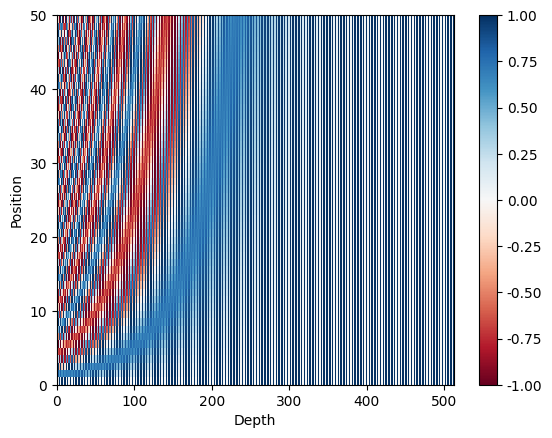

In [ ]:
# PE 시각화

sample_pos_encoding = PositionalEncoding(50, 512)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## Scaled Dot Product Attention

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 마스크가 주어졌다면 아주 작은 값을 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

## Multi Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output

## Padding Masking

In [ ]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

## Look-ahead masking

In [ ]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

## Encoder
- Multi Head Attention
- Feed Forward Neural Network

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2

In [ ]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

## Decoder
- Multi Head Attention
- Encoder-Decoder Attention
- Feed Forward Neural Network

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [ ]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

## Model Definition

In [ ]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [ ]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

# Model configuration

## Loss function

In [ ]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

## Custom Learning rate Scheduling

In [ ]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

## Optimizer

In [ ]:
# LambdaLR은 base_lr × lambda 로 곱하므로, get_lr_lambda 공식값을 그대로
# 실제 학습률로 쓰려면 base_lr=1.0 으로 두어야 합니다. (기본값 0.001이면 1/1000 스케일)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc.item()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

# Training

In [ ]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()

    enc_input, dec_input, target = [
        x.to(device) for x in batch
    ]

    # Gradient 초기화
    optimizer.zero_grad()

    # Forward
    logits = model(enc_input, dec_input)
    # [batch_size, MAX_LENGTH, VOCAB_SIZE]

    # Loss 계산
    loss = loss_function(
        logits.permute(0, 2, 1),
        target
    )
    # logits:
    # [batch_size, VOCAB_SIZE, MAX_LENGTH]
    #
    # target:
    # [batch_size, MAX_LENGTH]

    # Backpropagation
    loss.backward()

    # Parameter update
    optimizer.step()

    # Accuracy
    accuracy = accuracy_function(
        logits,
        target,
        pad_id=sp.pad_id()
    )

    return loss.item(), accuracy

In [ ]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):

        total_loss = 0
        total_acc = 0

        for step, batch in enumerate(dataloader):

            loss, acc = train_step(
                model,
                batch,
                optimizer,
                loss_function,
                device
            )

            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(
                    f"[Epoch {epoch+1}, Step {step}] "
                    f"Loss: {loss:.4f}, "
                    f"Acc: {acc:.4f}"
                )

            # 현재 scheduler는 batch 단위 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        # epoch 결과 저장
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        print(
            f"Epoch {epoch+1} Completed - "
            f"Avg Loss: {avg_loss:.4f}, "
            f"Avg Acc: {avg_acc:.4f}"
        )

    return loss_history, acc_history

In [ ]:
%%time

loss_history, acc_history = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,
    device=device
)

[Epoch 1, Step 0] Loss: 9.0983, Acc: 0.0000
[Epoch 1, Step 100] Loss: 7.5463, Acc: 0.2804
[Epoch 1, Step 200] Loss: 6.6390, Acc: 0.2727
[Epoch 1, Step 300] Loss: 6.2819, Acc: 0.2845
Epoch 1 Completed - Avg Loss: 7.0509, Avg Acc: 0.2397
[Epoch 2, Step 0] Loss: 6.0591, Acc: 0.2768
[Epoch 2, Step 100] Loss: 5.4019, Acc: 0.3436
[Epoch 2, Step 200] Loss: 5.8541, Acc: 0.2857
[Epoch 2, Step 300] Loss: 6.0204, Acc: 0.2529
Epoch 2 Completed - Avg Loss: 5.6747, Avg Acc: 0.3005
[Epoch 3, Step 0] Loss: 5.2189, Acc: 0.3190
[Epoch 3, Step 100] Loss: 5.0595, Acc: 0.3250
[Epoch 3, Step 200] Loss: 4.9528, Acc: 0.3417
[Epoch 3, Step 300] Loss: 5.1346, Acc: 0.3254
Epoch 3 Completed - Avg Loss: 5.1835, Avg Acc: 0.3201
[Epoch 4, Step 0] Loss: 4.5942, Acc: 0.3491
[Epoch 4, Step 100] Loss: 4.5540, Acc: 0.3641
[Epoch 4, Step 200] Loss: 4.8442, Acc: 0.3190
[Epoch 4, Step 300] Loss: 4.2129, Acc: 0.4205
Epoch 4 Completed - Avg Loss: 4.6902, Avg Acc: 0.3463
[Epoch 5, Step 0] Loss: 4.6473, Acc: 0.3137
[Epoch 5, St

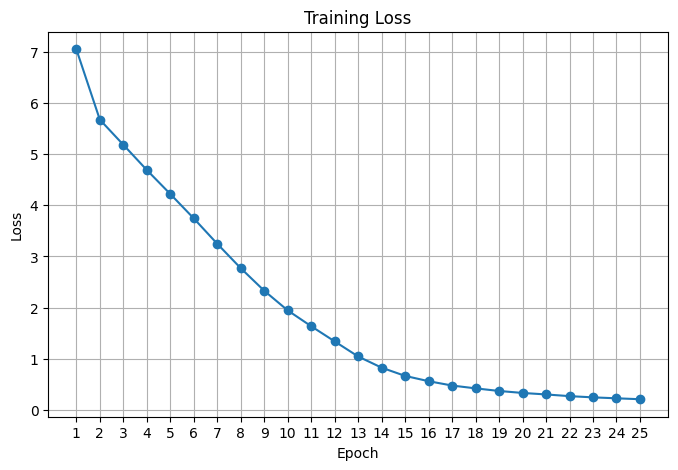

In [ ]:
# loss rate 시각화

epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.xticks(epochs)
plt.grid(True)
plt.show()

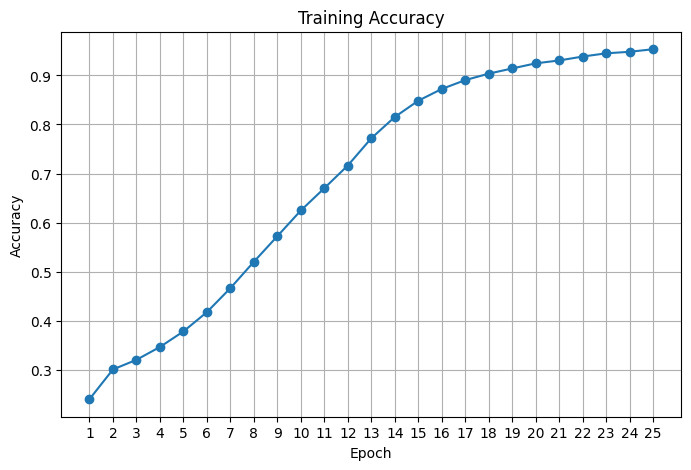

In [ ]:
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.show()

# Test

In [ ]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    PAD_TOKEN = tokenizer.pad_id()

    MAX_LENGTH = 20

    # 학습 데이터와 동일한 전처리
    sentence = sentence.strip()
    sentence = ' '.join(sentence.split())

    # SentencePiece 인코딩
    sentence_ids = tokenizer.encode(
        sentence,
        out_type=int
    )

    # Encoder 입력
    enc_input_ids = (
        [START_TOKEN]
        + sentence_ids
        + [END_TOKEN]
    )

    # MAX_LENGTH 초과 방지
    enc_input_ids = enc_input_ids[:MAX_LENGTH]

    # Padding
    enc_input_ids += [
        PAD_TOKEN
    ] * (MAX_LENGTH - len(enc_input_ids))

    # Tensor 변환
    enc_input = torch.tensor(
        [enc_input_ids],
        dtype=torch.long,
        device=device
    )

    # Decoder는 BOS부터 시작
    dec_input = torch.tensor(
        [[START_TOKEN]],
        dtype=torch.long,
        device=device
    )

    model.eval()

    with torch.no_grad():

        for _ in range(MAX_LENGTH - 1):

            # Transformer forward
            logits = model(
                enc_input,
                dec_input
            )

            # 마지막 위치의 예측값
            last_step_logits = logits[:, -1, :]

            # 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(
                last_step_logits,
                dim=-1
            )

            # EOS가 나오면 생성 종료
            if predicted_id.item() == END_TOKEN:
                break

            # [1] → [1, 1]
            predicted_id = predicted_id.unsqueeze(0)

            # Decoder input에 토큰 추가
            dec_input = torch.cat(
                [dec_input, predicted_id],
                dim=1
            )

    # BOS 제거
    output_ids = dec_input.squeeze(0).tolist()[1:]

    # SentencePiece로 문장 복원
    response = tokenizer.decode(output_ids)

    return response

In [ ]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스
    predicted_sentence = decoder_inference(
        model,
        sentence,
        tokenizer,
        device=device
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)

    return predicted_sentence

In [ ]:
# 새로운 데이터로 테스트

test_sentences = [
    "오늘 너무 힘들어.",
    "나랑 영화 보러 갈래?",
    "요즘 기분이 별로야.",
    "너는 어떤 음식을 좋아해?",
    "오늘 날씨가 정말 좋네."
]

for sentence in test_sentences:
    print("=" * 50)

    sentence_generation(
        model,
        sentence,
        sp,
        device=device
    )

입력 : 오늘 너무 힘들어.
출력 : 무슨 마음인지 알겠어서 더 마음이 아프네요.
입력 : 나랑 영화 보러 갈래?
출력 : 좋아요!
입력 : 요즘 기분이 별로야.
출력 : 힘내세요.
입력 : 너는 어떤 음식을 좋아해?
출력 : 어떤 음식을 좋아하는지 물어보고 맛집을 찾아봐요.
입력 : 오늘 날씨가 정말 좋네.
출력 : 좋은 사람이 찾아오려나봐요.


In [ ]:
# 학습 데이터로 테스트

for i in range(10):

    print("=" * 60)

    question = questions[i]
    answer = answers[i]

    prediction = sentence_generation(
        model,
        question,
        sp,
        device=device
    )

    print("질문 :", question)
    print("정답 :", answer)
    print("예측 :", prediction)

입력 : 12시 땡!
출력 : 하루가 또 가네요.
질문 : 12시 땡!
정답 : 하루가 또 가네요.
예측 : 하루가 또 가네요.
입력 : 1지망 학교 떨어졌어
출력 : 위로해 드립니다.
질문 : 1지망 학교 떨어졌어
정답 : 위로해 드립니다.
예측 : 위로해 드립니다.
입력 : 3박4일 놀러가고 싶다
출력 : 여행은 언제나 좋죠.
질문 : 3박4일 놀러가고 싶다
정답 : 여행은 언제나 좋죠.
예측 : 여행은 언제나 좋죠.
입력 : 3박4일 정도 놀러가고 싶다
출력 : 여행은 언제나 좋죠.
질문 : 3박4일 정도 놀러가고 싶다
정답 : 여행은 언제나 좋죠.
예측 : 여행은 언제나 좋죠.
입력 : PPL 심하네
출력 : 눈살이 찌푸려지죠.
질문 : PPL 심하네
정답 : 눈살이 찌푸려지죠.
예측 : 눈살이 찌푸려지죠.
입력 : SD카드 망가졌어
출력 : 다시 새로 사는 게 마음 편해요.
질문 : SD카드 망가졌어
정답 : 다시 새로 사는 게 마음 편해요.
예측 : 다시 새로 사는 게 마음 편해요.
입력 : SD카드 안돼
출력 : 다시 새로 사는 게 마음 편해요.
질문 : SD카드 안돼
정답 : 다시 새로 사는 게 마음 편해요.
예측 : 다시 새로 사는 게 마음 편해요.
입력 : SNS 맞팔 왜 안하지ㅠㅠ
출력 : 잘 모르고 있을 수도 있어요.
질문 : SNS 맞팔 왜 안하지ㅠㅠ
정답 : 잘 모르고 있을 수도 있어요.
예측 : 잘 모르고 있을 수도 있어요.
입력 : SNS 시간낭비인 거 아는데 매일 하는 중
출력 : 시간을 정하고 해보세요.
질문 : SNS 시간낭비인 거 아는데 매일 하는 중
정답 : 시간을 정하고 해보세요.
예측 : 시간을 정하고 해보세요.
입력 : SNS 시간낭비인데 자꾸 보게됨
출력 : 시간을 정하고 해보세요.
질문 : SNS 시간낭비인데 자꾸 보게됨
정답 : 시간을 정하고 해보세요.
예측 : 시간을 정하고 해보세요.


# Analysis

## 1. 실험 개요

한국어 `ChatbotData.csv` 데이터셋을 이용하여 SentencePiece 기반 Transformer Encoder-Decoder 챗봇을 학습하였다.

주요 설정은 다음과 같다.

* **Tokenizer:** SentencePiece BPE
* **Vocabulary size:** 8,000
* **MAX_LENGTH:** 20
* **Batch size:** 32
* **Transformer Encoder/Decoder layer:** 2
* **D_MODEL:** 256
* **Attention heads:** 8
* **Feed Forward dimension:** 512
* **Dropout:** 0.1
* **Optimizer:** Adam
* **Learning rate:** Transformer warm-up 방식의 LambdaLR
* **Epoch:** 25
* **학습 시간:** 약 2분 59초

---

## 2. Training Loss 분석

학습 결과 Loss는 **Epoch 1의 7.0509에서 Epoch 25의 0.2089까지 지속적으로 감소**하였다.

| Epoch |       Loss |   Accuracy |
| ----: | ---------: | ---------: |
|     1 |     7.0509 |     0.2397 |
|     5 |     4.2210 |     0.3779 |
|    10 |     1.9454 |     0.6246 |
|    15 |     0.6647 |     0.8484 |
|    20 |     0.3315 |     0.9246 |
|    25 | **0.2089** | **0.9534** |

특히 Epoch 1~10 구간에서 Loss가 빠르게 감소하였다.

```text
7.0509 → 5.6747 → 5.1835 → 4.6902 → 4.2210
→ 3.7440 → 3.2477 → 2.7702 → 2.3298 → 1.9454
```

이후에도 꾸준히 감소하여 Epoch 25에서는 **0.2089**까지 낮아졌다.

이는 모델이 학습 과정에서 질문과 답변 사이의 관계 및 답변의 토큰 패턴을 효과적으로 학습했음을 보여준다.

---

## 3. Training Accuracy 분석

Accuracy 역시 Epoch 1의 **23.97%에서 Epoch 25의 95.34%까지 지속적으로 증가**하였다.

```text
Epoch 1  : 23.97%
Epoch 5  : 37.79%
Epoch 10 : 62.46%
Epoch 15 : 84.84%
Epoch 20 : 92.46%
Epoch 25 : 95.34%
```

특히 Epoch 10 이후 Accuracy가 빠르게 상승하였다.

* Epoch 10: 62.46%
* Epoch 15: 84.84%
* Epoch 20: 92.46%
* Epoch 25: 95.34%

따라서 학습 데이터에 존재하는 정답 토큰을 정확하게 예측하는 능력은 상당히 높은 수준까지 향상되었다고 볼 수 있다.


---

# 4. 실제 문장 생성 결과 분석

학습 데이터에 없는 테스트 문장을 입력한 결과도 확인하였다.

### 테스트 결과

| 입력             | 생성 결과                       | 평가              |
| -------------- | --------------------------- | --------------- |
| 오늘 너무 힘들어.     | 무슨 마음인지 알겠어서 더 마음이 아프네요.    | 자연스러운 답변        |
| 나랑 영화 보러 갈래?   | 좋아요!                        | 자연스러운 답변        |
| 요즘 기분이 별로야.    | 힘내세요.                       | 적절한 답변          |
| 너는 어떤 음식을 좋아해? | 어떤 음식을 좋아하는지 물어보고 맛집을 찾아봐요. | 다소 어색하지만 관련성 있음 |
| 오늘 날씨가 정말 좋네.  | 좋은 사람이 찾아오려나봐요.             | 문맥상 부자연스러움   |

전체적으로 입력 문장의 의도와 관련된 답변을 생성하는 모습을 확인할 수 있었다.

모델이 단순히 무작위 문장을 생성하는 것이 아니라 입력 문장의 의미적 특징을 어느 정도 학습하고 있음을 확인할 수 있다.

---

# 5. 학습 데이터에 대한 결과

학습 데이터의 질문을 다시 입력하여 실제 정답과 비교한 결과, 테스트한 10개의 샘플에서 **모든 예측이 정답과 정확하게 일치하였다.**

예를 들어:

```text
질문 : 12시 땡!
정답 : 하루가 또 가네요.
예측 : 하루가 또 가네요.
```

```text
질문 : PPL 심하네
정답 : 눈살이 찌푸려지죠.
예측 : 눈살이 찌푸려지죠.
```

```text
질문 : SNS 시간낭비인데 자꾸 보게됨
정답 : 시간을 정하고 해보세요.
예측 : 시간을 정하고 해보세요.
```

등에서 정확한 답변을 생성하였다.

이는 앞서 관찰된 Training Accuracy와도 일관된 결과이다.


---

# 6. 현재 모델의 종합 평가

### 긍정적인 부분

1. Loss가 7.0509 → 0.2089로 크게 감소하였다.
2. Training Accuracy가 23.97% → 95.34%로 크게 향상되었다.
3. 학습이 25 Epoch 동안 안정적으로 진행되었다.
4. 학습 데이터의 질문에 대해 정답 답변을 정확하게 생성하였다.
5. 학습 데이터에 없는 새로운 질문에도 어느 정도 자연스러운 답변을 생성하였다.
6. 답변이 무작위로 반복되는 심각한 collapse 현상은 관찰되지 않았다.
7. 약 3분 이내에 전체 25 Epoch 학습이 완료되어 실험 속도도 양호하다.

### 개선이 필요한 부분

1. 높은 Training Accuracy가 데이터 암기의 결과일 가능성이 있다.
2. 일부 새로운 질문에서는 질문의 의도와 직접적으로 관련되지 않는 답변이 생성된다.
3. 현재 평가는 주로 Token Accuracy에 의존하고 있어 실제 문장 생성 품질을 충분히 평가하지 못한다.
4. 테스트 문장 수가 적기 때문에 모델의 전반적인 성능을 판단하기에는 부족하다.